In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import h5py, os, pzflow
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from pzflow import Flow
from pzflow.bijectors import Chain, ShiftBounds, RollingSplineCoupling, StandardScaler
from pzflow.distributions import Uniform, Normal, CentBeta, CentBeta13

from msi.utils import input_output, plotting, mcmc
from msfm.utils import prior, parameters, files

24-01-17 01:56:32   imports.py INF   Setting up healpy to run on 256 CPUs 


### settings

In [3]:
# bumping up the precision from float32 to float64 seems to be beneficial
from jax.config import config
config.update("jax_enable_x64", True)

# network predictions

### v3

In [4]:
# base_dir = "/pscratch/sd/a/athomsen/run_files/v3"
# # base_dir = "/Users/arne/data/DESY3/models/v3/"

In [5]:
# # clustering only

# # legacy vanilla
# # model_dir = "2023-05-30_01-48-23_resnet_vanilla"

# # new vanilla
# model_dir = "2023-08-17_08-50-56_resnet_vanilla"

# # Jacobian unlike the identity
# # model_dir = "2023-08-17_08-23-47_resnet_vanilla"

# # mean subtracted from all maps
# # model_dir = "2023-08-17_08-38-03_resnet_vanilla"

# # mean subtracted and divide by std for all maps
# # model_dir = "2023-08-17_08-19-09_resnet_vanilla"

# n_steps = 50000
# params = ["Om", "s8", "bg", "n_bg"]



In [6]:
# # lensing only
# model_dir = "2023-05-29_09-55-49_resnet_vanilla"
# n_steps = 50000
# params = ["Om", "s8", "Aia", "n_Aia"]

In [7]:
# # combined probes
# model_dir = "2023-05-30_10-56-53_resnet_vanilla"
# n_steps = 10000
# params = ["Om", "s8", "Aia", "n_Aia", "bg", "n_bg"]

### v4

In [8]:
# base_dir = "/pscratch/sd/a/athomsen/run_files/v4"

In [9]:
# # clustering only

# # large_scales (8 Mpc/h)
# model_dir = "2023-08-25_05-40-02_resnet_vanilla"

# # large scales (12 Mpc/h) and first redshift bin only
# model_dir = "2023-08-29_08-42-16_resnet_vanilla"

# large scales (12 Mpc/h) and third redshift bin only
# model_dir = "2023-08-30_04-21-53_resnet_vanilla"

# # extra large scales (8 Mpc/h, but no factor of pi as with Al)
# model_dir = "2023-08-30_09-31-59_resnet_vanilla"

# # GRF, extra large scales (8 Mpc/h "physical")
# model_dir = "grf/2023-09-06_03-29-03_resnet_vanilla"

# GRF, 8 Mpc/h "physical", 2nd run
# model_dir  = "grf/2023-09-06_09-08-40_resnet_vanilla"

# original data, 8 Mpc/h "physical", for direct comparison with immediately above
# model_dir = "2023-09-06_09-45-08_resnet_vanilla"

# n_steps = 20000
# params = ["Om", "s8", "bg", "n_bg"]

In [10]:
# # lensing only

# # large_scales (6 Mpc/h)
# model_dir = "2023-08-28_04-29-33_resnet_vanilla"

# n_steps = 50000
# params = ["Om", "s8", "Aia", "n_Aia"]

In [11]:
# # combined probes

# # all parameters
# model_dir = "2023-08-31_03-29-47_resnet_vanilla"

# n_steps = 20000
# params = ["Om", "s8", "H0", "Ob", "ns", "w0", "Aia", "n_Aia", "bg", "n_bg"]

### v5

In [12]:
# # clustering (linear bias)
# base_dir = "/pscratch/sd/a/athomsen/run_files/v5/linear_bias"
# model_dir = "2023-10-02_19-48-47_resnet_vanilla"

# n_steps = 40000
# params = ["Om", "s8", "bg", "n_bg"]

In [13]:
# clustering (quadratic bias)

# n_steps = 40000
# params = ["Om", "s8", "bg", "n_bg", "bg2", "n_bg2"]

In [14]:
# clustering (stochasticity)

# n_steps = 40000
# params = ["Om", "s8", "bg", "n_bg"]

In [15]:
# lensing

# n_steps = 50000
# params = ["Om", "s8", "Aia", "n_Aia"]

In [16]:
# combined

# n_steps = 20000
# params = ["Om", "s8", "H0", "Ob", "ns", "w0", "Aia", "n_Aia", "bg", "n_bg"]

### v6

In [17]:
# lensing
conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v6/linear_bias.yaml")
base_dir = "/pscratch/sd/a/athomsen/run_files/v6/lensing_only"

# delta loss
model_dir = "delta/2024-01-12_19-35-59_resnet_vanilla"

# MSE loss
# model_dir = "mse/2024-01-08_03-05-03_resnet_vanilla"

# likelihood loss
# model_dir = "mse/2024-01-05_22-04-15_resnet_vanilla"
# model_dir = "mse/2024-01-08_06-13-14_resnet_vanilla"

n_steps = 100000
params = ["Om", "s8", "w0", "Aia", "n_Aia"]

### general

In [18]:
# fidu_vali_preds, grid_preds, grid_cosmos, grid_sobol = input_output.load_preds(base_dir, model_dir, n_steps)

# # reduce the number of examples per cosmology
# # grid_preds = grid_preds[:,:4,:]

# out_dir = os.path.join(base_dir, model_dir)

In [19]:
file_dict = input_output.load_preds(base_dir, model_dir, n_steps)

fidu_preds = file_dict["fiducial/vali/pred"]
grid_preds = file_dict["grid/pred"]
grid_cosmos = file_dict["grid/cosmo"]
grid_sobol = file_dict["grid/i_sobol"]

n_params = len(params)
n_cosmos = grid_preds.shape[0]
n_examples = grid_preds.shape[1]
n_summaries = grid_preds.shape[2]
summary_labels = [f"summary_{i}" for i in range(n_summaries)]

24-01-17 01:56:35 input_output INF   Array shapes:
 
24-01-17 01:56:35 input_output INF   fiducial/vali/pred = (4, 5) 
24-01-17 01:56:35 input_output INF   grid/pred          = (2500, 48, 5) 
24-01-17 01:56:35 input_output INF   grid/cosmo         = (2500, 5) 
24-01-17 01:56:35 input_output INF   grid/i_sobol       = (2500,) 
24-01-17 01:56:35 input_output INF   grid/i_example     = (2500, 48) 
24-01-17 01:56:35 input_output INF   grid/i_noise       = (2500, 48) 


In [20]:
# # assert fidu_train_preds.shape[1] == fidu_vali_preds.shape[1] == grid_preds.shape[2]
# assert fidu_vali_preds.shape[1] == grid_preds.shape[2]

# n_params = len(params)
# n_cosmos = grid_preds.shape[0]
# n_examples = grid_preds.shape[1]
# n_summaries = grid_preds.shape[2]
# summary_labels = [f"summary_{i}" for i in range(n_summaries)]

In [21]:
train_test_split = 0.8

# construct the dataframe
df_list = []
for i in range(n_examples):

    df_sobol = pd.DataFrame(grid_sobol, columns=["sobol"])

    df_cosmo = pd.DataFrame()
    for j, param in enumerate(params):
        df_cosmo[param] = grid_cosmos[:,j]

    df_summary = pd.DataFrame()
    for j in range(n_summaries):
        df_summary[f"summary_{j}"] = grid_preds[:,i,j]

    df_list.append(df_sobol.join([df_cosmo, df_summary]))

# combine along the example axis
df_total = pd.concat(df_list, axis=0)
df_total = df_total.sample(frac=1.0)

# train/test split
df_train = df_total[: int(train_test_split * len(df_total))]
df_val = df_total[int(train_test_split* len(df_total)) :]

### observation

In [22]:
# # fiducial
# # obs_pred = np.median(fidu_vali_preds, axis=0)
# # obs_pred = np.mean(fidu_vali_preds, axis=0)
# obs_pred = fidu_vali_preds[0]
# fiducial_point = None

# # i_median = np.argmin(np.sum(np.square(np.median(fidu_cls, axis=0, keepdims=True) - fidu_cls), axis=-1))
# # print(f"The example index closest to the median is {i_median}")
# # obs_cls = fidu_cls[np.newaxis, i_median]

# # # grid
# # i_cosmo = 0
# # obs_pred = grid_preds[i_cosmo,0,:]
# # fiducial_point = dict(zip(params, [grid_cosmos[i_cosmo,j] for j in range(len(params))]))

# obs_df = pd.DataFrame([obs_pred], columns=[f"summary_{i}" for i in range(n_summaries)])

In [23]:
i_obs = 1

# i_obs = np.argmin(np.sum(np.square(np.median(fidu_preds, axis=0, keepdims=True) - fidu_preds), axis=-1))
# print(f"The example index closest to the median is {i_obs}")

obs_pred = fidu_preds[i_obs]
obs_df = pd.DataFrame([obs_pred], columns=[f"summary_{i}" for i in range(n_summaries)])

In [24]:
out_dir = os.path.join(base_dir, model_dir)
label = f"{n_steps}_flow_like_large"

# normalizing flow

## learn the likelihood $p(s | \theta)$

 15%|█▍        | 148/1000 [02:07<12:15,  1.16it/s] 

Early stopping criterion is met. Training stopping after epoch 149.


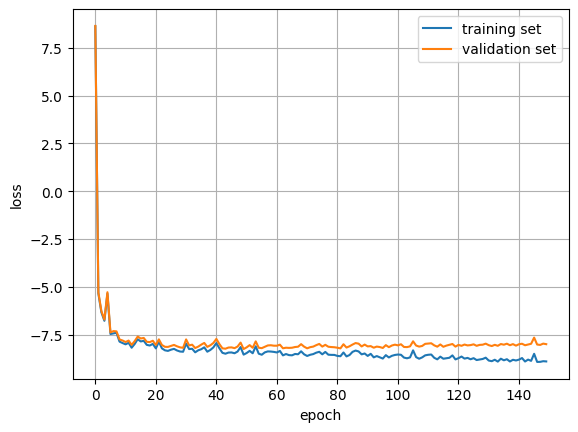

In [25]:
latent = CentBeta13(input_dim=n_summaries, B=5)
bijector = Chain(
    ShiftBounds(jnp.array(df_total[summary_labels].min(axis=0)), jnp.array(df_total[summary_labels].max(axis=0)), B=4),
    RollingSplineCoupling(2*n_summaries, B=5, n_conditions=n_params, hidden_dim=256),
)

flow = Flow(
    data_columns=summary_labels, 
    conditional_columns=params, 
    latent=latent,
    bijector=bijector,
)

# train with validation set and early stopping
loss_train, loss_val = flow.train(df_train, df_val, epochs=1000, patience=100, best_params=True, verbose=False, progress_bar=True)

# train on all of the data
# flow = Flow(
#     data_columns=summary_labels, 
#     conditional_columns=params, 
#     latent=latent,
#     bijector=bijector,
# )
# n_epochs = len(loss_train)
# loss_all = flow.train(df_total, epochs=n_epochs, verbose=False, progress_bar=True)

# plot
fig, ax = plt.subplots()
ax.plot(loss_train, label="training set")
ax.plot(loss_val, label="validation set")
# ax.plot(loss_all, label="full set")
ax.set(xlabel="epoch", ylabel="loss")
ax.legend()
ax.grid(True)

## density estimation checks

In [26]:
# # sample from the flow
# n_samples_per_cosmo = 1000
# df_cosmo = pd.DataFrame(grid_cosmos, columns=params)
# pred_samples = flow.sample(n_samples_per_cosmo, conditions=df_cosmo)

# pred_samples_array = pred_samples.to_numpy().reshape(n_cosmos, n_samples_per_cosmo, n_summaries + n_params)

In [27]:
# # network predictions
# mean_preds = np.mean(grid_preds, axis=1)
# std_preds = np.std(grid_preds, axis=1, ddof=1)

# # flow samples
# mean_samples = pred_samples.groupby(params, sort=False).mean().to_numpy()
# std_samples = pred_samples.groupby(params, sort=False).std(ddof=1).to_numpy()

# assert mean_preds.shape == std_preds.shape == mean_samples.shape == std_samples.shape

# # test statistics, these should be tightly centered around zero
# Delta_mu = (mean_samples - mean_preds)/std_preds
# Delta_sigma = (std_samples - std_preds)/std_preds

# Delta_mu = Delta_mu.ravel()
# Delta_sigma = Delta_sigma.ravel()

# # plot
# fig, ax = plt.subplots(ncols=2, figsize=(16,6), sharey=True)

# ax[0].hist(Delta_mu, bins=50, density=True)
# ax[0].set(title="relative mean statistic", xlabel=r"$\Delta_\mu$", ylabel="probability density")
# ax[0].grid(True)

# ax[1].hist(Delta_sigma, bins=50, density=True)
# ax[1].set(title="relative spread statistic", xlabel=r"$\Delta_\sigma$")
# ax[1].grid(True)


# fig, ax = plt.subplots(figsize=(16,4), ncols=n_summaries)

# bin_mins = np.quantile(std_samples, 0.01, axis=0)
# bin_maxs = np.quantile(std_samples, 0.99, axis=0)
# bins = np.linspace(bin_mins, bin_maxs, 20)

# for i in range(n_summaries):
#     ax[i].hist(std_preds[:,i], bins=bins[:,i], label="network predictions", density=True, alpha=0.5)
#     ax[i].hist(std_samples[:,i], bins=bins[:,i], label="samples from flow", density=True, alpha=0.5)

#     ax[i].set(title=f"summary {i}", xlabel="std")
#     ax[i].grid(True)

# ax[0].legend()
# ax[0].set(ylabel="probability density")

In [28]:
# # random grid cosmologies
# n_indices = 10
# cosmo_indices = np.random.randint(0, n_cosmos, n_indices)

# fig, ax = plt.subplots(figsize=(5*n_summaries, 3*n_indices), nrows=n_indices, ncols=n_summaries, sharex="col", sharey="col")

# for i, i_cosmo in enumerate(cosmo_indices):
#     for j in range(n_summaries):
#         current_sample = pred_samples_array[i_cosmo,:,j]
#         current_true = grid_preds[i_cosmo,:,j]
                        
#         current_all = np.concatenate([current_sample, current_true]).ravel()
#         current_min = np.quantile(current_all, 0.01)
#         current_max = np.quantile(current_all, 0.99)
#         current_bins = np.linspace(current_min, current_max, 30)

#         ax[i,j].hist(current_sample, bins=current_bins, density=True, label="mixture model samples", alpha=0.5)
#         ax[i,j].hist(current_true, bins=current_bins, density=True, label="summary network predictions", alpha=0.5)

#         # cosmetics
#         ax[i,j].grid(True)
        
#         if i==0:
#             ax[i,j].set(title=f"summary {j}")
        
#         if j==0:
#             ax[i,j].set(ylabel=f"example {i_cosmo}")
            
#         if i==0 and j==0:
#             ax[i,j].legend(loc="upper left")

### MCMC

In [29]:
# # sample from the flow
# n_samples_per_cosmo = 1000
# # df_cosmo = pd.DataFrame(grid_cosmos, columns=params)
# pred_samples = flow.sample(n_samples_per_cosmo, conditions=obs_df)

# # pred_samples_array = pred_samples.to_numpy().reshape(n_cosmos, n_samples_per_cosmo, n_summaries + n_params)

In [30]:
def log_likelihood(X): 
    # convert to dataframe
    X = pd.DataFrame(X, columns=params)
    X = X.join(obs_df, how="cross")

    # evaluate the normalizing flow
    log_prob = flow.log_prob(X)
    
    # enforce the prior
    log_prob = prior.log_posterior(X.loc[:,params], log_prob, params=params, conf=None)

    return log_prob

In [31]:
chain = mcmc.run_emcee(
    log_likelihood,
    params,
    out_dir=out_dir,
    label=label,
    n_walkers=2048,
    n_steps=500,
)

24-01-17 01:59:00      mcmc.py INF   Initial values in prior: True 


100%|██████████| 500/500 [03:52<00:00,  2.15it/s]


### plot

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

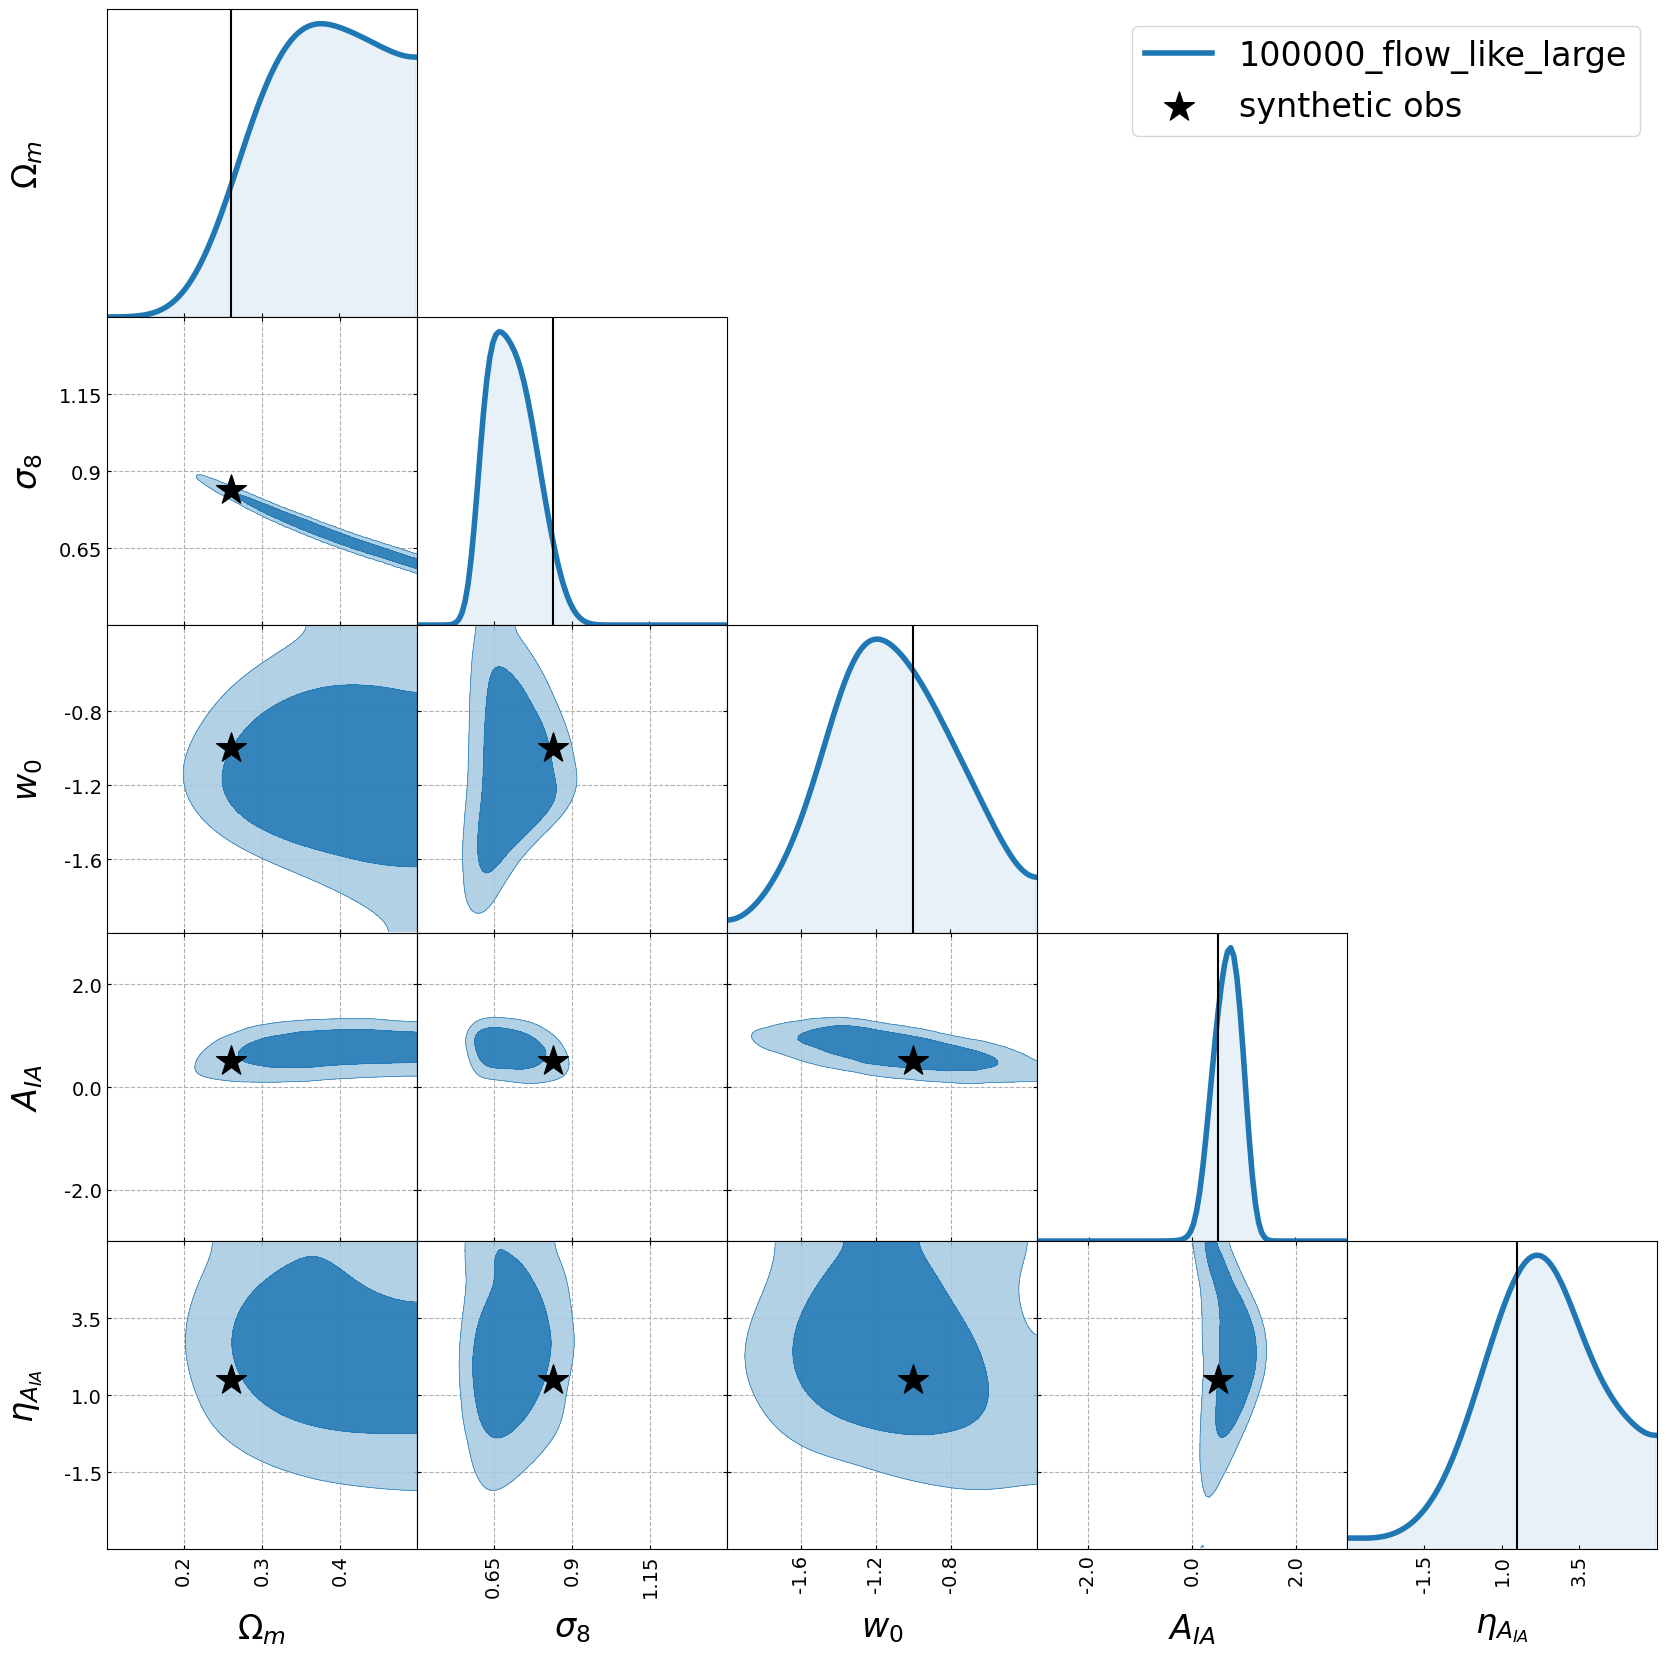

In [32]:
plotting.plot_chains(
    chain, 
    params, 
    out_dir=out_dir, 
    labels=label,
    # fiducial_point=fiducial_point,
)

## learn the posterior $p(\theta | s)$

In [33]:
# label = f"{n_steps}_flow_posterior"

In [34]:
# latent = CentBeta13(input_dim=n_params, B=5)
# bijector = Chain(
#     ShiftBounds(jnp.array(df_total[params].min(axis=0)), jnp.array(df_total[params].max(axis=0)), B=4),
#     RollingSplineCoupling(n_params, B=5, n_conditions=n_summaries, hidden_dim=128),
# )

# flow = Flow(
#     data_columns=params, 
#     conditional_columns=summary_labels, 
#     latent=latent,
#     bijector=bijector,
# )

# # train
# loss_train, loss_val = flow.train(df_train, df_val, verbose=True, epochs=500, batch_size=2048)
# # loss_train = flow.train(df_total, verbose=True, epochs=100)

# # plot
# fig, ax = plt.subplots()
# ax.plot(loss_train, label="training set")
# ax.plot(loss_val, label="validation set")
# ax.set(xlabel="epoch", ylabel="loss")
# ax.legend()
# ax.grid(True)

### direct sampling

In [35]:
# %%time

# # sample directly from the normalizing flow
# samples = flow.sample(1000000, conditions=obs_df, save_conditions=False)

# # check whether all of the parameter values are within the prior
# assert list(samples.columns) == params
# prior_mask = prior.in_grid_prior(samples, params=params)
# samples = samples[prior_mask]

# # convert to numpy and save
# chain = samples.to_numpy()

# if out_dir is not None:
#     np.save(os.path.join(out_dir, f"chain_{label}.npy"), chain)

In [36]:
# plotting.plot_chain(
#     chain, 
#     params, 
#     out_dir=out_dir, 
#     label=label,
# )